In [1]:
import pandas as pd
import missingno
import numpy as np
import matplotlib.pyplot as plt

import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

enc = 'utf-8' 
dec = 'greek8'

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
raw_data_2021 = pd.read_csv('../data/GR_WNV_cases_2010-2021.csv', encoding = enc)
raw_data_2021.head(5)

,αα,Id διαχείρισης δεδομένων,Έτος,Ηλικία \n(σε έτη),Φύλο,Ημ/νία έναρξης συμπτωμάτων,Προσβολή ΚΝΣ (ΝΑΙ/ΟΧΙ),Περιφέρεια πιθανής έκθεσης,Περιφερειακή ενότητα πιθανής έκθεσης,Δήμος πιθανής έκθεσης,Πόλη/χωριό (/συνοικία Αθήνας) πιθανής έκθεσης,Κωδικός κανάβου κελιού 1x1 χλμ πιθανής έκθεσης,Unnamed: 12
0,1.0,3.0,2010.0,75.0,ΘΗΛΥ,28-07-10,NAI,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Θεσσαλονίκης,"Παπάφη, Θεσσαλονίκη",NaN,NaN
1,2.0,17.0,2010.0,78.0,ΑΡΡΕΝ,22-07-10,NAI,Κεντρικής Μακεδονίας,Ημαθίας,Βέροιας,Βέροια,NaN,NaN
2,3.0,4.0,2010.0,70.0,ΘΗΛΥ,24-07-10,NAI,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Λεβεντοχώρι,NaN,NaN
3,4.0,21.0,2010.0,74.0,ΑΡΡΕΝ,30-7-2010,NAI,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Καμπάνη,NaN,NaN
4,5.0,59.0,2010.0,19.0,ΘΗΛΥ,06-07-10,NAI,Κεντρικής Μακεδονίας,Σερρών,Ηράκλειας,Ποντισμένο,NaN,NaN


In [4]:
raw_data_2022 = pd.read_csv('../data/GR_WNV_cases_2022.csv', encoding = enc)
raw_data_2022.head(5)

,Έτος,Ημ/νία έναρξης συμπτωμάτων,Περιφέρεια πιθανής έκθεσης,Περιφερειακή ενότητα πιθανής έκθεσης,Δήμος πιθανής έκθεσης,Αριθμός ασθενών ΜΕ εκδηλώσεις από το ΚΝΣ,Αριθμός ασθενών ΧΩΡΙΣ εκδηλώσεις από το ΚΝΣ,Συνολικός αριθμός ασθενών
0,2022,12-07-22,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Αμπελοκήπων - Μενεμένης,1,0,1
1,2022,19-07-22,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Δέλτα,2,0,2
2,2022,19-07-22,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Χαλκηδόνος,1,0,1
3,2022,16-07-22,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Δέλτα,1,0,1
4,2022,16-07-22,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Θέρμης,1,0,1


In [5]:
raw_data_2021.shape

(1421, 13)

In [6]:
raw_data_2022.shape

(177, 8)

In [7]:
data_2021 = raw_data_2021.set_axis(['idx', 'id', 'year', 'age', 'sex', 'onset of symptoms', 'cns attack', 'nuts2', 'nuts3', 'lau1', 'lau2', 'cell_code', 'unnamed'], axis=1, inplace=False)
data_2022 = raw_data_2022.set_axis(['year', 'onset of symptoms', 'nuts2', 'nuts3', 'lau1', 'cases_CNS', 'cases_WO_CNS', 'cases'], axis=1, inplace=False)

In [8]:
data_2021.drop(columns = ['idx', 'id', 'cell_code', 'unnamed'], inplace = True)
data_2021.dropna(axis = 0, subset = ['onset of symptoms', 'lau1'], how = 'any', inplace = True)
data_2021['onset of symptoms'] = data_2021['onset of symptoms'].apply(lambda x : x.replace("~", ""))
data_2021 = data_2021[data_2021['onset of symptoms'] != 'Άγνωστη']
data_2021 = data_2021[data_2021['nuts2'] != 'Άγνωστη']
data_2021 = data_2021[data_2021['nuts2'] != 'Απροσδιόριστη']
data_2021 = data_2021[data_2021['nuts2'] != 'Απροσδιόριστη (Ανατολικής Μακεδονίας & Θράκης Ή Κεντρικής Μακεδονίας)']
data_2021['onset of symptoms'] = pd.to_datetime(data_2021['onset of symptoms'], dayfirst=True, errors='coerce')
data_2021['cases'] = 1
data_2021 = data_2021.astype({"year":'int'})

In [9]:
data_2021.drop(columns = ['age', 'sex', 'cns attack', 'lau1', 'lau2'], inplace = True)


In [10]:
data_2021

,year,onset of symptoms,nuts2,nuts3,cases
0,2010,2010-07-28,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1
1,2010,2010-07-22,Κεντρικής Μακεδονίας,Ημαθίας,1
2,2010,2010-07-24,Κεντρικής Μακεδονίας,Κιλκίς,1
3,2010,2010-07-30,Κεντρικής Μακεδονίας,Κιλκίς,1
4,2010,2010-07-06,Κεντρικής Μακεδονίας,Σερρών,1
...,...,...,...,...,...
1414,2021,2021-08-31,Ανατολικής Μακεδονίας & Θράκης,Καβάλας,1
1415,2021,2021-09-13,Κεντρικής Μακεδονίας,Ημαθίας,1
1416,2021,2021-09-03,Κεντρικής Μακεδονίας,Ημαθίας,1
1418,2021,2021-10-04,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1


In [11]:
data_2022.drop(columns = ['lau1', 'cases_CNS', 'cases_WO_CNS'], inplace = True)
data_2022['onset of symptoms'] = pd.to_datetime(data_2022['onset of symptoms'], dayfirst=True, errors='coerce')

In [12]:
data_2022

,year,onset of symptoms,nuts2,nuts3,cases
0,2022,2022-07-12,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1
1,2022,2022-07-19,Κεντρικής Μακεδονίας,Θεσσαλονίκης,2
2,2022,2022-07-19,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1
3,2022,2022-07-16,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1
4,2022,2022-07-16,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1
...,...,...,...,...,...
172,2022,2022-10-18,Θεσσαλίας,Λάρισας,1
173,2022,2022-10-18,Ανατολικής Μακεδονίας και Θράκης,Δράμας,1
174,2022,2022-10-18,Ιονίων Νήσων,Λευκάδας,1
175,2022,2022-10-25,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1


In [14]:
data_2021.cases.unique()


array([1], dtype=int64)

In [15]:
data_2022.cases.unique()

array([ 1,  2,  4,  3,  6,  5, 10], dtype=int64)

In [16]:
data_2021_grouped = data_2021.groupby(['year', 'onset of symptoms',	'nuts2', 'nuts3'], as_index = False)
data_2021 = data_2021_grouped.sum()

In [17]:
data_2021.cases.unique()

array([1, 2, 3, 4, 5, 6], dtype=int64)

In [18]:
data_2021.head()

,year,onset of symptoms,nuts2,nuts3,cases
0,2010,2010-07-06,Κεντρικής Μακεδονίας,Σερρών,1
1,2010,2010-07-16,Κεντρικής Μακεδονίας,Κιλκίς,1
2,2010,2010-07-18,Κεντρικής Μακεδονίας,Πέλλας,1
3,2010,2010-07-19,Κεντρικής Μακεδονίας,Θεσσαλονίκης,2
4,2010,2010-07-20,Κεντρικής Μακεδονίας,Ημαθίας,1


In [19]:
data_2022.head()

,year,onset of symptoms,nuts2,nuts3,cases
0,2022,2022-07-12,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1
1,2022,2022-07-19,Κεντρικής Μακεδονίας,Θεσσαλονίκης,2
2,2022,2022-07-19,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1
3,2022,2022-07-16,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1
4,2022,2022-07-16,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1


In [20]:
data = pd.concat([data_2021,data_2022], ignore_index=True)

In [21]:
data

,year,onset of symptoms,nuts2,nuts3,cases
0,2010,2010-07-06,Κεντρικής Μακεδονίας,Σερρών,1
1,2010,2010-07-16,Κεντρικής Μακεδονίας,Κιλκίς,1
2,2010,2010-07-18,Κεντρικής Μακεδονίας,Πέλλας,1
3,2010,2010-07-19,Κεντρικής Μακεδονίας,Θεσσαλονίκης,2
4,2010,2010-07-20,Κεντρικής Μακεδονίας,Ημαθίας,1
...,...,...,...,...,...
1301,2022,2022-10-18,Θεσσαλίας,Λάρισας,1
1302,2022,2022-10-18,Ανατολικής Μακεδονίας και Θράκης,Δράμας,1
1303,2022,2022-10-18,Ιονίων Νήσων,Λευκάδας,1
1304,2022,2022-10-25,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1


In [22]:
data.dropna(axis = 0, subset = ['onset of symptoms'], how = 'any', inplace = True)

In [23]:
data.reset_index(drop=True, inplace=True)

In [24]:
data

,year,onset of symptoms,nuts2,nuts3,cases
0,2010,2010-07-06,Κεντρικής Μακεδονίας,Σερρών,1
1,2010,2010-07-16,Κεντρικής Μακεδονίας,Κιλκίς,1
2,2010,2010-07-18,Κεντρικής Μακεδονίας,Πέλλας,1
3,2010,2010-07-19,Κεντρικής Μακεδονίας,Θεσσαλονίκης,2
4,2010,2010-07-20,Κεντρικής Μακεδονίας,Ημαθίας,1
...,...,...,...,...,...
1301,2022,2022-10-18,Θεσσαλίας,Λάρισας,1
1302,2022,2022-10-18,Ανατολικής Μακεδονίας και Θράκης,Δράμας,1
1303,2022,2022-10-18,Ιονίων Νήσων,Λευκάδας,1
1304,2022,2022-10-25,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1


<AxesSubplot:>

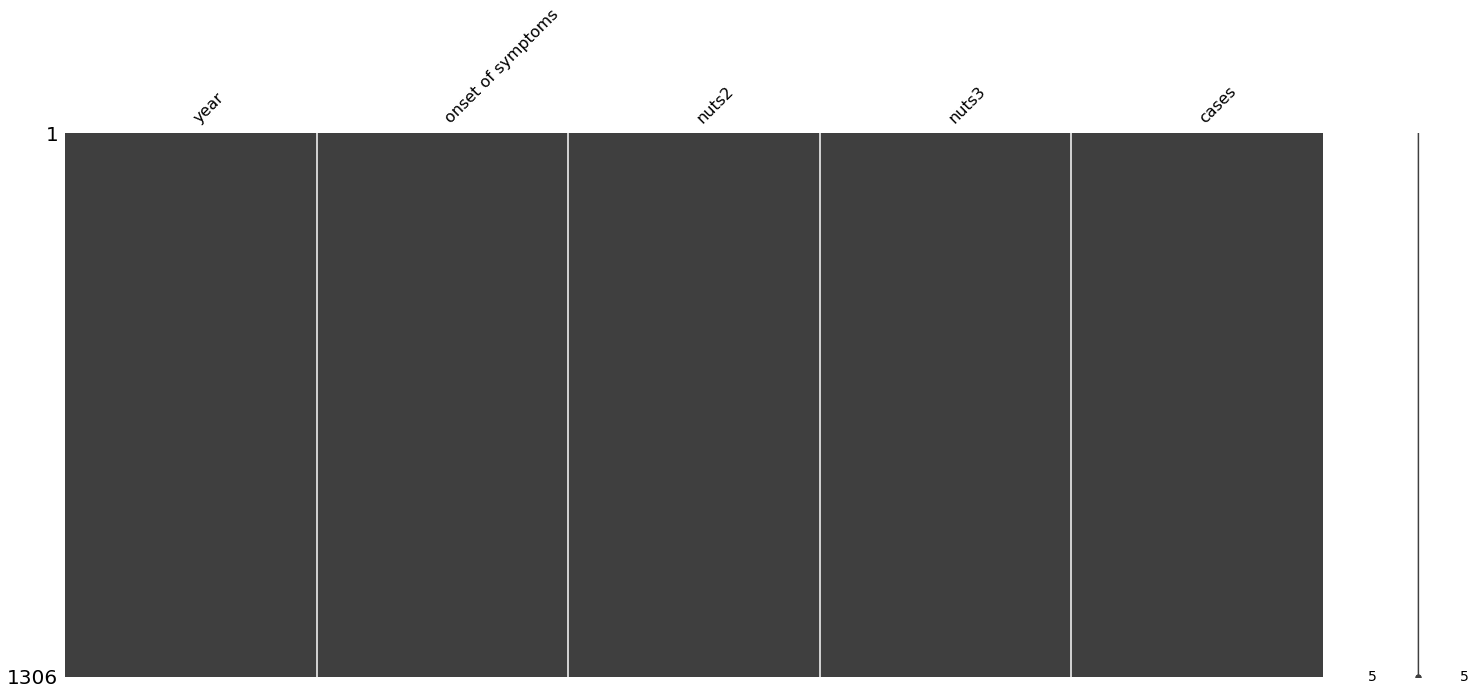

In [25]:
missingno.matrix(data)

In [26]:
data.cases.unique()

array([ 1,  2,  3,  4,  5,  6, 10], dtype=int64)

In [27]:
process_greek(data, 'nuts2')
process_greek(data, 'nuts3')

data['day'] = data['onset of symptoms'].apply(lambda x : x.day)
data['month'] = data['onset of symptoms'].apply(lambda x : x.month)

In [28]:
data = data.reindex(columns=['onset of symptoms', 'year', 'month', 'day', 'nuts2', 'nuts3', 'cases'])

In [29]:
data

,onset of symptoms,year,month,day,nuts2,nuts3,cases
0,2010-07-06,2010,7,6,κεντρικης μακεδονιας,σερρων,1
1,2010-07-16,2010,7,16,κεντρικης μακεδονιας,κιλκις,1
2,2010-07-18,2010,7,18,κεντρικης μακεδονιας,πελλας,1
3,2010-07-19,2010,7,19,κεντρικης μακεδονιας,θεσσαλονικης,2
4,2010-07-20,2010,7,20,κεντρικης μακεδονιας,ημαθιας,1
...,...,...,...,...,...,...,...
1301,2022-10-18,2022,10,18,θεσσαλιας,λαρισας,1
1302,2022-10-18,2022,10,18,ανατολικης μακεδονιας και θρακης,δραμας,1
1303,2022-10-18,2022,10,18,ιονιων νησων,λευκαδας,1
1304,2022-10-25,2022,10,25,κεντρικης μακεδονιας,θεσσαλονικης,1


In [30]:
data.to_csv("../data/GR_WNV_cases_2010-2022_processed.csv", encoding = enc, index = False)

In [31]:
data = convert_multiple_cases(data, target_col = 'cases')

In [32]:
data

,onset of symptoms,year,month,day,nuts2,nuts3,cases
0,2010-07-06,2010,7,6,κεντρικης μακεδονιας,σερρων,1
1,2010-07-16,2010,7,16,κεντρικης μακεδονιας,κιλκις,1
2,2010-07-18,2010,7,18,κεντρικης μακεδονιας,πελλας,1
3,2010-07-19,2010,7,19,κεντρικης μακεδονιας,θεσσαλονικης,1
4,2010-07-20,2010,7,20,κεντρικης μακεδονιας,ημαθιας,1
...,...,...,...,...,...,...,...
1664,2022-09-20,2022,9,20,θεσσαλιας,λαρισας,1
1665,2022-09-20,2022,9,20,θεσσαλιας,λαρισας,1
1666,2022-09-20,2022,9,20,θεσσαλιας,λαρισας,1
1667,2022-09-20,2022,9,20,θεσσαλιας,λαρισας,1


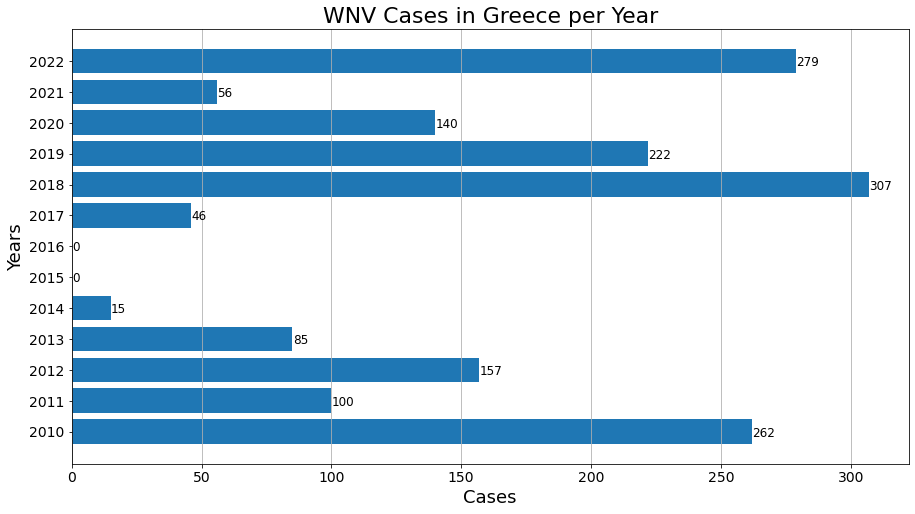

In [33]:
years = [year for year in range(2010, 2023)]
cases = [len(data.query(f"year == {year}")) for year in years]

plt.figure(num = None, figsize = (15,8), facecolor='w', edgecolor='b')
#plt.bar(years, cases)
plt.barh(years, cases)

#ax.bar_label(bars)
y_t = plt.xticks(np.arange(0, max(cases) + 10, step = 50), size = 14)
x_t = plt.yticks(np.arange(min(years), max(years) + 1, step = 1), size = 14)
x_l  = plt.ylabel('Years', size = 18)
y_l =  plt.xlabel('Cases', size = 18)
title = plt.title('WNV Cases in Greece per Year', size = 22)
for year, case in zip(years,cases):
    plt.text(case+0.15, year-0.15, str(case), size = 12)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()

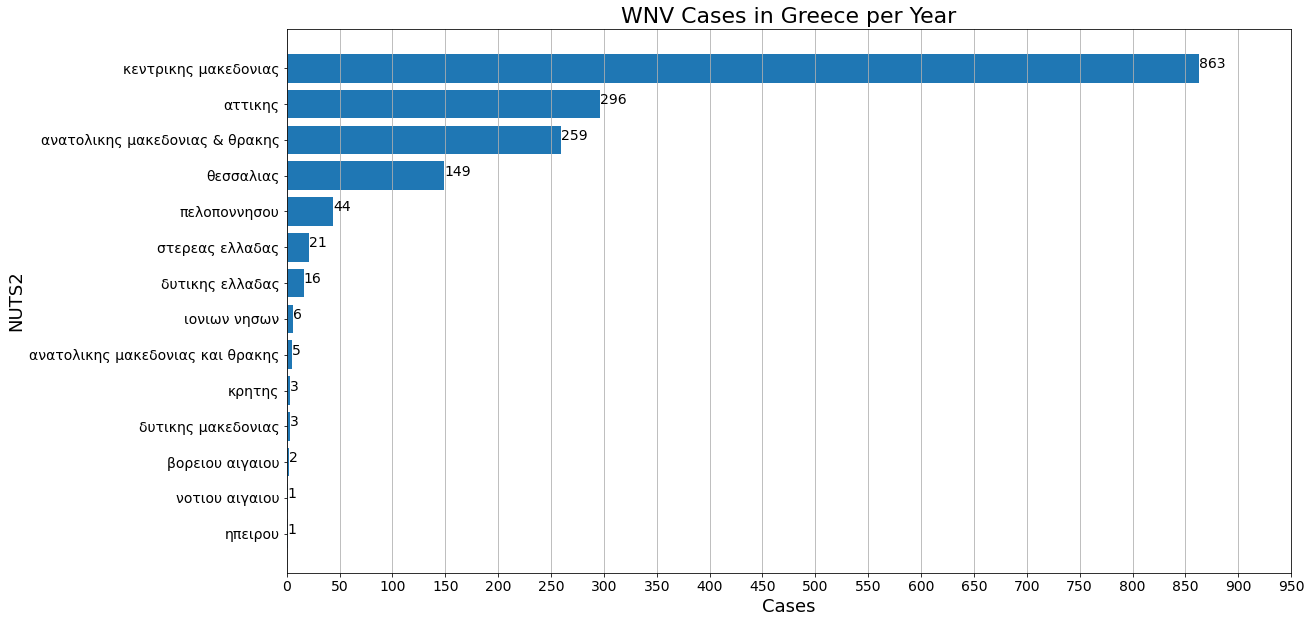

In [34]:
nuts2 = data['nuts2'].drop_duplicates().sort_values().tolist()
cases = [len(data.query(f"nuts2 == '{nuts2_unit}'")) for nuts2_unit in nuts2]

cases, nuts2 = zip(*sorted(zip(cases, nuts2)))

plt.figure(num = None, figsize = (18,10), facecolor='w', edgecolor='b')
plt.barh(nuts2, cases)

y_t = plt.xticks(np.arange(0, max(cases) + 100, step = 50), size = 14)
x_t = plt.yticks(nuts2, size = 14)
x_l  = plt.ylabel('NUTS2', size = 18)
y_l =  plt.xlabel('Cases', size = 18)
title = plt.title('WNV Cases in Greece per Year', size = 22)
for nuts2, case in zip(nuts2,cases):
    plt.text(case+0.15, nuts2, str(case), size = 14)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()

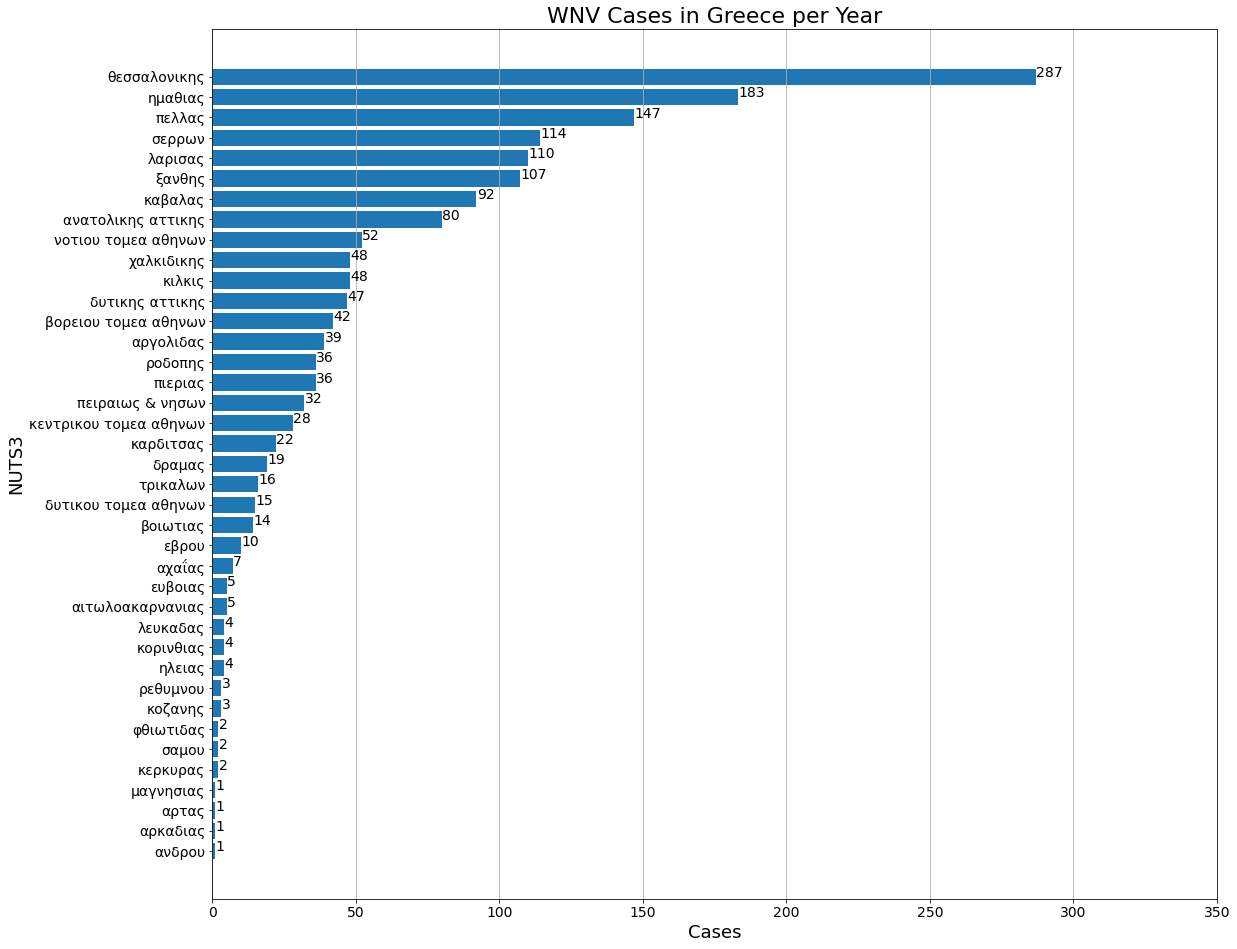

In [35]:
nuts3 = data['nuts3'].drop_duplicates().sort_values().tolist()
cases = [len(data.query(f"nuts3 == '{nuts2_unit}'")) for nuts2_unit in nuts3]

cases, nuts3 = zip(*sorted(zip(cases, nuts3)))

plt.figure(num = None, figsize = (18,16), facecolor='w', edgecolor='b')
plt.barh(nuts3, cases)

y_t = plt.xticks(np.arange(0, max(cases) + 100, step = 50), size = 14)
x_t = plt.yticks(nuts3, size = 14)
x_l  = plt.ylabel('NUTS3', size = 18)
y_l =  plt.xlabel('Cases', size = 18)
title = plt.title('WNV Cases in Greece per Year', size = 22)
for nuts3, case in zip(nuts3,cases):
    plt.text(case+0.15, nuts3, str(case), size = 14)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()